In [1]:
import os
os.getcwd()  

'/Users/owerko/PycharmProjects/NASA/Landsat8'

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import rasterio.mask as rmask
import fiona as fio


In [3]:
def read_landsat_images(folder_name):
    file_list = os.listdir(folder_name)
    channel_list = []
    for f in file_list:
        if (f.startswith('LC') and f.endswith('.tif')):
            if 'band' in f:
                channel_list.append(folder_name + f)
    channel_list.sort()
    channel_numbers = np.arange(1, 8)
    bands_dictionary = dict(zip(channel_numbers, channel_list))
    return bands_dictionary


In [4]:
# satellite_images = read_landsat_images('/Users/tomek/OneDrive - Akademia Górniczo-Hutnicza im. Stanisława Staszica w Krakowie/Geoinformatyka/Landsat8/LC08') #- przykład sciezka bezwzgledna
satellite_images = read_landsat_images('LC08')

In [5]:
for band in satellite_images:
    print(band, satellite_images[band])


1 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band1.tif
2 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band2.tif
3 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band3.tif
4 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band4.tif
5 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band5.tif
6 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band6.tif
7 LC08LC08_L1TP_188025_20130807_20170503_01_T1_sr_band7.tif


In [6]:
def show_band(band, color_map='gray'):
    fig = plt.figure(figsize=(8, 8))
    image_layer = plt.imshow(band)
    image_layer.set_cmap(color_map)
    plt.colorbar()
    plt.show()


def show_band2(band, color_map='gray', remove_negative=True):
    matrix = band.astype(float)
    if remove_negative:
        matrix[matrix <= 0] = np.nan
    fig = plt.figure(figsize=(8, 8))
    image_layer = plt.imshow(matrix)
    image_layer.set_cmap(color_map)
    plt.colorbar()
    # plt.savefig('plot.tif')
    plt.show()


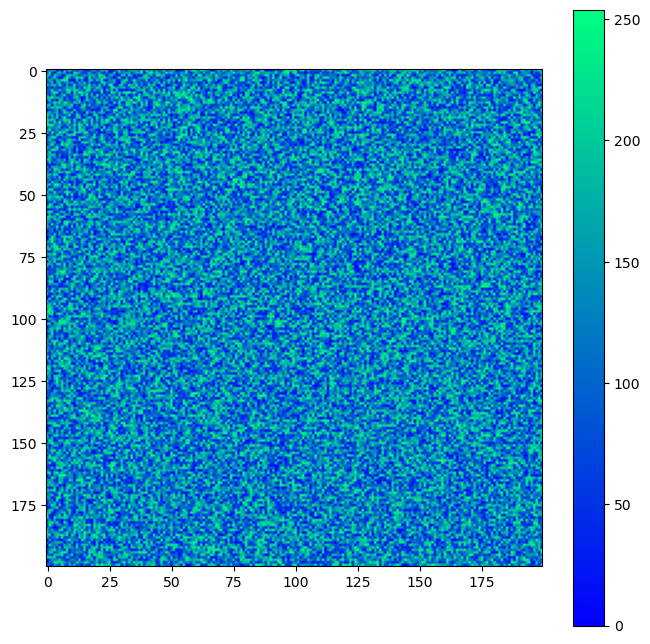

LC08/LC08_L1TP_188025_20130807_20170503_01_T1_sr_band5.tif


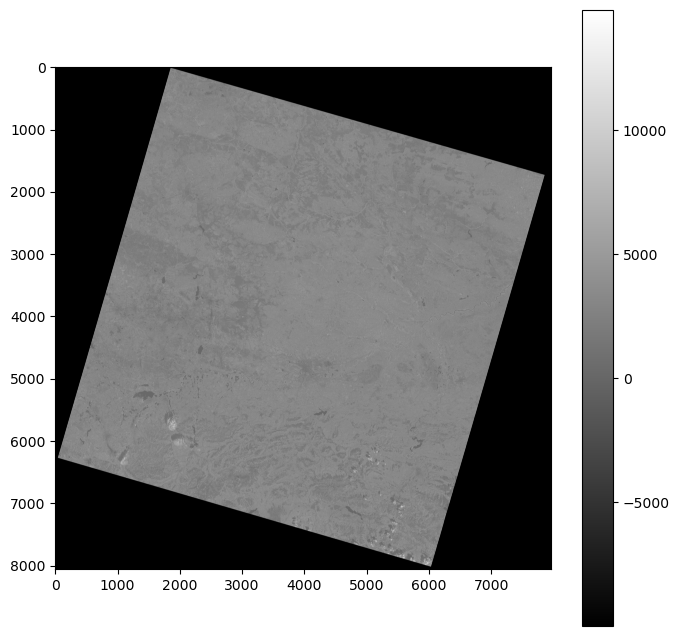

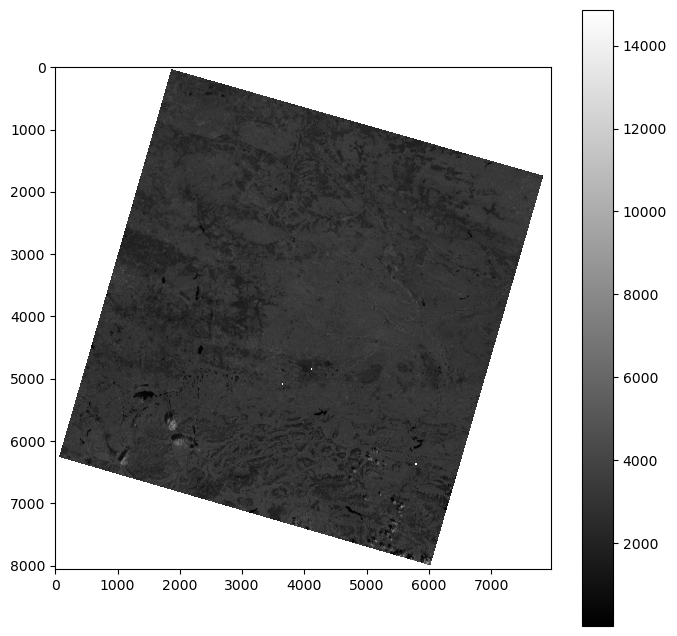

In [7]:
test = np.random.randint(low=0, high=255, size=(200, 200))
show_band(test, color_map='winter')

band_list = read_landsat_images('LC08/')

print(band_list[5])

with rio.open(band_list[5], 'r') as src:
    band_matrix = src.read(1)

show_band(band_matrix)
show_band2(band_matrix)


In [8]:
def clip_area(vector_file, raster_file, save_image_to):
    with fio.open(vector_file, 'r') as clipper:
        geometry = [feature["geometry"] for feature in clipper]

    with rio.open(raster_file, 'r') as raster_source:
        clipped_image, transform = rmask.mask(raster_source, geometry, crop=True)
        metadata = raster_source.meta.copy()

    metadata.update({"driver": "GTiff",
                     "height": clipped_image.shape[1],
                     "width": clipped_image.shape[2],
                     "transform": transform})
    with rio.open(save_image_to, "w", **metadata) as g_tiff:
        g_tiff.write(clipped_image)


clipped/LC_clipped_band1.tif
clipped/LC_clipped_band2.tif
clipped/LC_clipped_band3.tif
clipped/LC_clipped_band4.tif
clipped/LC_clipped_band5.tif
clipped/LC_clipped_band6.tif
clipped/LC_clipped_band7.tif


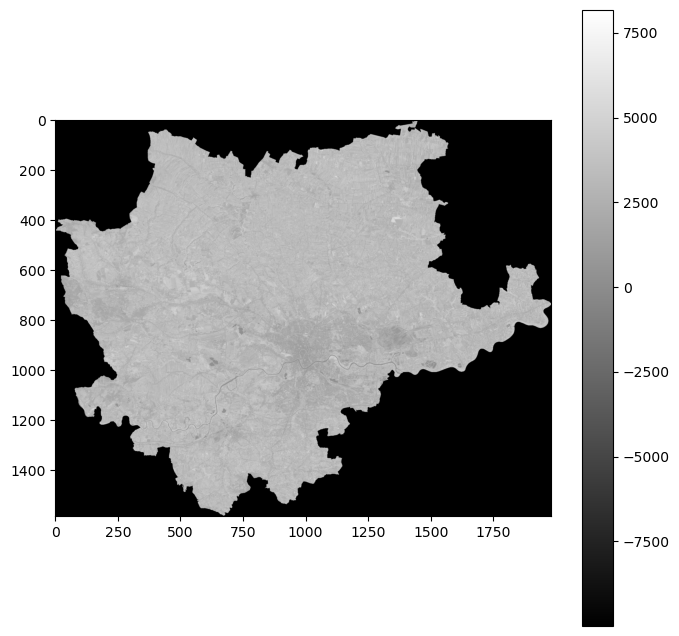

In [9]:
# bands = read_landsat_images('/Users/tomek/OneDrive - Akademia Górniczo-Hutnicza im. Stanisława Staszica w Krakowie/Geoinformatyka/Landsat8/LC08/')

# vector = '/Users/tomek/OneDrive - Akademia Górniczo-Hutnicza im. Stanisława Staszica w Krakowie/Geoinformatyka/Landsat8/vector/krakow_krakowskie.shp'
# clipped_folder = '/Users/tomek/OneDrive - Akademia Górniczo-Hutnicza im. Stanisława Staszica w Krakowie/Geoinformatyka/Landsat8/clipped/'

# bands = read_landsat_images('LC08')
# vector = 'vector/krakow_krakowskie.shp'
# clipped_folder = '/Users/owerko/PycharmProjects/NASA/Landsat8/clipped'
# print(clipped_folder)

bands = read_landsat_images('LC08/')

vector = 'vector/krakow_krakowskie.shp'
clipped_folder = 'clipped/'
for band in bands:
    destination = clipped_folder + 'LC_clipped_band' + str(band) + '.tif'
    clip_area(vector, bands[band], destination)

clipped_bands = read_landsat_images('clipped/')
for band in clipped_bands:
    print(clipped_bands[band])

with rio.open(clipped_bands[5], 'r') as src:
    band_matrix = src.read(1)

show_band(band_matrix)


In [10]:
def calculate_index(index_name, landsat_8_bands):
    indexes = {
        'ndvi': (5, 4),
        'ndbi': (6, 5),
        'ndwi': (3, 6),
    }

    # Magiczne 10000 przez które dzielone są piksele poszczególnych obrazów
    # to maksymalna wartość pikseli w produktach poziomu 2 satelity Landsat 8

    if index_name in indexes:
        bands = indexes[index_name]

        with rio.open(landsat_8_bands[bands[0]]) as a:
            band_a = (a.read()[0] / 10000).astype(float)
        with rio.open(landsat_8_bands[bands[1]]) as b:
            band_b = (b.read()[0] / 10000).astype(float)

        numerator = band_a - band_b
        denominator = band_a + band_b

        idx = numerator / denominator
        idx[idx > 1] = 1
        idx[idx < -1] = -1
        return idx
    else:
        raise ValueError('Brak wskaźnika do wyboru, dostępne wskaźniki to ndbi, ndvi i ndwi')




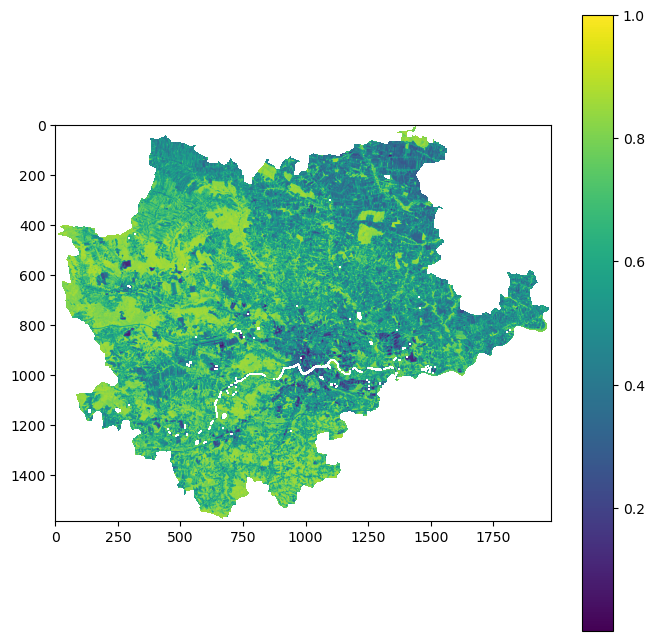

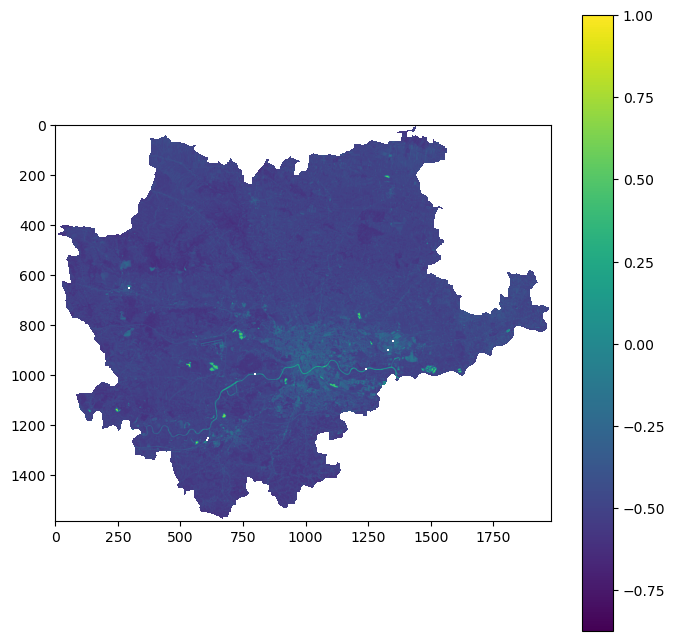

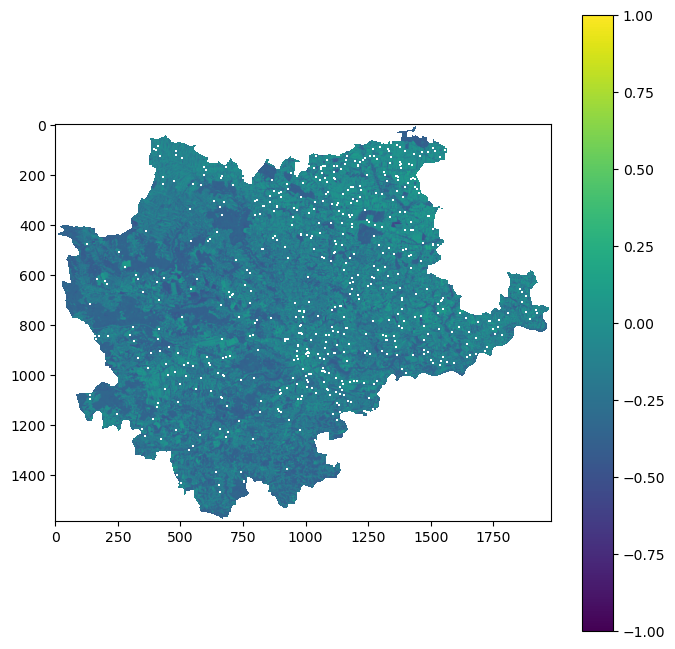

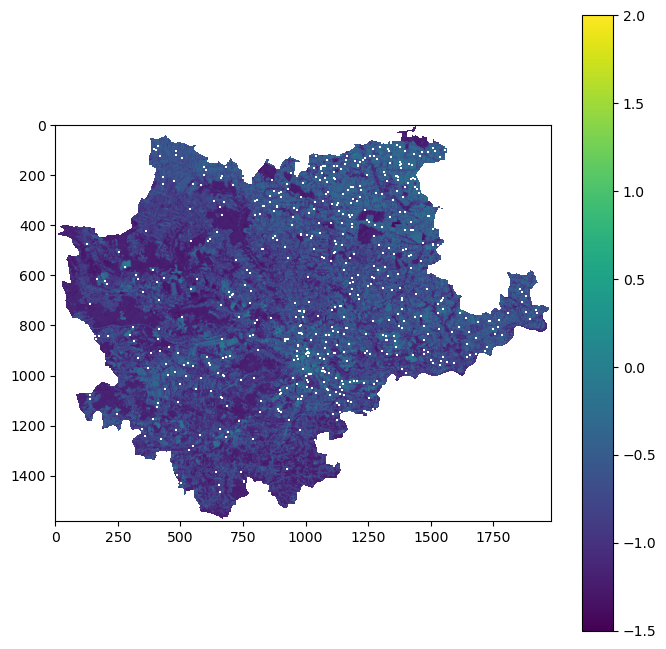

In [11]:
ndvi = calculate_index('ndvi', clipped_bands)
ndvi[ndvi == 0] = -1
show_band2(ndvi, color_map='viridis', remove_negative=True)

ndwi = calculate_index('ndwi', clipped_bands)
ndwi[ndwi == 0] = np.nan
show_band2(ndwi, color_map='viridis', remove_negative=False)

ndbi = calculate_index('ndbi', clipped_bands)
ndbi[ndbi == 0] = np.nan
show_band2(ndbi, color_map='viridis', remove_negative=False)

show_band2(ndbi - ndvi, color_map='viridis', remove_negative=False)

In [ ]:
#TODO w iTerm:

# Zmieniamy nasz GeoTIFF na plik 8-bitowy (założona nazwa pliku który mamy z QGIS to NDVI.tif)
# gdal_translate -of GTiff -ot byte NDVI.tif NDVI8.tif

# Generujemy warstwy prezentacji w postaci KML (Google EARTH), plików HTML (leaflet.html, openlayers.html) 
# gdal2tiles.py -s EPSG:32634 -k NDVI8.tif (gdzie NDVI8.tif to plik wynikowy poprzedniego polecenia)
